# Feature store validation

This notebook reads the **published offline store** on SeaweedFS over the S3 API,
not the warehouse. That is deliberate: it exercises the same path a training
pipeline or another team would use, so anything broken about the hand-off shows up
here rather than in someone else's job.

What it checks, in order:

1. Feature discovery straight from the registry that ships with the data
2. Point-in-time safety - can a feature see past its own as-of date?
3. Dormancy - `all_time` must persist while bounded windows decay
4. Window monotonicity on real rows
5. Exact vs approximate distinct counts
6. Assembling a training set with a point-in-time-correct as-of join

In [1]:
import json, os
from pathlib import Path
import duckdb, pandas as pd

S3_ENDPOINT = os.getenv('S3_ENDPOINT', 'localhost:8433')
BUCKET      = os.getenv('FS_GOLD_BUCKET', 'gold')
FEATURE     = 'fact_agg_features_login_history_v2'

con = duckdb.connect()
con.execute('install httpfs; load httpfs;')
con.execute(f"set s3_endpoint='{S3_ENDPOINT}'")
con.execute(f"set s3_access_key_id='{os.getenv('S3_ACCESS_KEY','featuremart')}'")
con.execute(f"set s3_secret_access_key='{os.getenv('S3_SECRET_KEY','featuremart')}'")
con.execute("set s3_use_ssl=false; set s3_url_style='path'; set s3_region='us-east-1'")

STORE = f's3://{BUCKET}/feature_store/{FEATURE}/*/*.parquet'

# hive_partitioning recovers target_date from the directory name, so a
# consumer never has to know how the partitions were laid out.
con.execute(f"create or replace view features as "
            f"select * from read_parquet('{STORE}', hive_partitioning=true)")

shape = con.execute('''
    select count(*) as n_rows,
           count(distinct target_date) as n_snapshots,
           count(distinct safe_id) as n_entities
    from features
''').df()
print(shape.to_string(index=False))

 n_rows  n_snapshots  n_entities
   2755           16         175


## 1. Feature discovery

The registry travels with the data. A consumer can resolve what every column means,
which spec version produced it, and how it was computed, without reading any SQL or
asking the owning team.

In [2]:
REGISTRY_DIR = Path(os.getenv('FS_REGISTRY_DIR', '../registry'))
reg = json.loads((REGISTRY_DIR / f'{FEATURE}.json').read_text())

print(f"feature set : {reg['feature_name']}")
print(f"spec version: {reg['spec_version']}   owner: {reg['owner']}")
print(f"expansion   : {reg['expansion']['atomic_fields']} atomic fields"
      f" x {len(reg['expansion']['condition_categories'])} condition categories"
      f" x {len(reg['expansion']['time_windows'])} windows"
      f" = {reg['expansion']['total_features']} features")
print(f"storage     : {reg['expansion']['partial_columns']} partial columns per entity-day")

cat = pd.DataFrame(reg['features'])
summary = (cat.groupby(['atomic_field','agg','materialisation'])
              .size().rename('features').reset_index())
summary

feature set : fact_agg_features_login_history_v2
spec version: 1bb528412532   owner: i.putra
expansion   : 4 atomic fields x 3 condition categories x 4 windows = 480 features
storage     : 96 partial columns per entity-day


,atomic_field,agg,materialisation,features
0,days_since_login,max,computed,48
1,days_since_login,min,computed,48
2,device_id,count_distinct,stored,48
3,event_id,count,stored,240
4,event_timestamp,max,stored,48
5,event_timestamp,min,stored,48


In [3]:
# Find features by meaning rather than by guessing at a name.
ios_late_night = cat[
    cat.conditions.apply(lambda c: c.get('login_os') == 'is_ios'
                                   and c.get('behavioural_time') == 'is_late_night')
]
ios_late_night[['name','agg','window','description']].head(8)

,name,agg,window,description
24,count_event_id_is_ios_is_late_night_l7d,count,l7d,"count of event_id for login_status=default, lo..."
25,count_event_id_is_ios_is_late_night_l14d,count,l14d,"count of event_id for login_status=default, lo..."
26,count_event_id_is_ios_is_late_night_l30d,count,l30d,"count of event_id for login_status=default, lo..."
27,count_event_id_is_ios_is_late_night_all_time,count,all_time,"count of event_id for login_status=default, lo..."
104,count_event_id_is_login_success_is_ios_is_late...,count,l7d,count of event_id for login_status=is_login_su...
105,count_event_id_is_login_success_is_ios_is_late...,count,l14d,count of event_id for login_status=is_login_su...
106,count_event_id_is_login_success_is_ios_is_late...,count,l30d,count of event_id for login_status=is_login_su...
107,count_event_id_is_login_success_is_ios_is_late...,count,all_time,count of event_id for login_status=is_login_su...


## 2. Point-in-time safety

The failure that quietly ruins a model: a feature dated day *D* that saw an event
from *D+1*. Offline it scores brilliantly, in production it collapses.

The design makes this structural - the partial layer refuses events after the as-of
date and every window is bounded above by it - but structural claims are worth
checking against the data.

In [4]:
leak = con.execute('''
    select count(*) as violations
    from features
    where _last_event_date > target_date
''').fetchone()[0]

print(f'rows whose newest observed event postdates their as-of date: {leak}')
assert leak == 0, 'FUTURE LEAKAGE'

# A stronger check: as the as-of date advances, an entity's all_time count may
# only ever grow. A drop would mean a past run had seen something it should not.
regress = con.execute('''
    with seq as (
        select safe_id, target_date, count_event_id_all_time as v,
               lag(count_event_id_all_time) over (
                   partition by safe_id order by target_date) as prev
        from features
    )
    select count(*) from seq where prev is not null and v < prev
''').fetchone()[0]
print(f'all_time counts that decreased over time: {regress}')
assert regress == 0, 'ALL_TIME REGRESSED'
print('\npoint-in-time safety: OK')

rows whose newest observed event postdates their as-of date: 0
all_time counts that decreased over time: 0

point-in-time safety: OK


## 3. Dormancy

This is the behaviour `all_time` was added for. A customer who stopped logging in
should show bounded windows decaying toward zero while `all_time` holds its history.
If `all_time` decayed too, it would just be a wider window; if the bounded windows
did not decay, they would be leaking.

In [5]:
dormant = con.execute('''
    with last_day as (select max(target_date) as d from features),
    -- entities with history but nothing recent, as of the newest snapshot
    picked as (
        select f.safe_id
        from features f, last_day l
        where f.target_date = l.d
          and f.count_event_id_all_time > 20
          and f.count_event_id_l7d = 0
    )
    select target_date,
           avg(count_event_id_l7d)      as l7d,
           avg(count_event_id_l14d)     as l14d,
           avg(count_event_id_l30d)     as l30d,
           avg(count_event_id_all_time) as all_time
    from features where safe_id in (select safe_id from picked)
    group by target_date order by target_date
''').df()

print(f'{len(dormant)} snapshots for the dormant cohort')
dormant

16 snapshots for the dormant cohort


,target_date,l7d,l14d,l30d,all_time
0,2026-08-20,2.708333,6.250000,13.375000,37.166667
1,2026-08-21,2.708333,6.125000,12.166667,37.458333
2,2026-08-22,2.541667,5.833333,12.416667,37.833333
3,2026-08-23,2.083333,5.166667,12.125000,37.916667
4,2026-08-24,2.250000,5.208333,12.291667,38.458333
5,2026-08-25,2.208333,5.041667,12.166667,38.750000
6,2026-08-28,3.250000,5.958333,12.416667,40.708333
7,2026-08-31,3.833333,6.083333,13.208333,42.291667
8,2026-09-01,4.125000,6.333333,13.250000,42.875000
9,2026-09-02,3.458333,5.791667,12.958333,42.875000


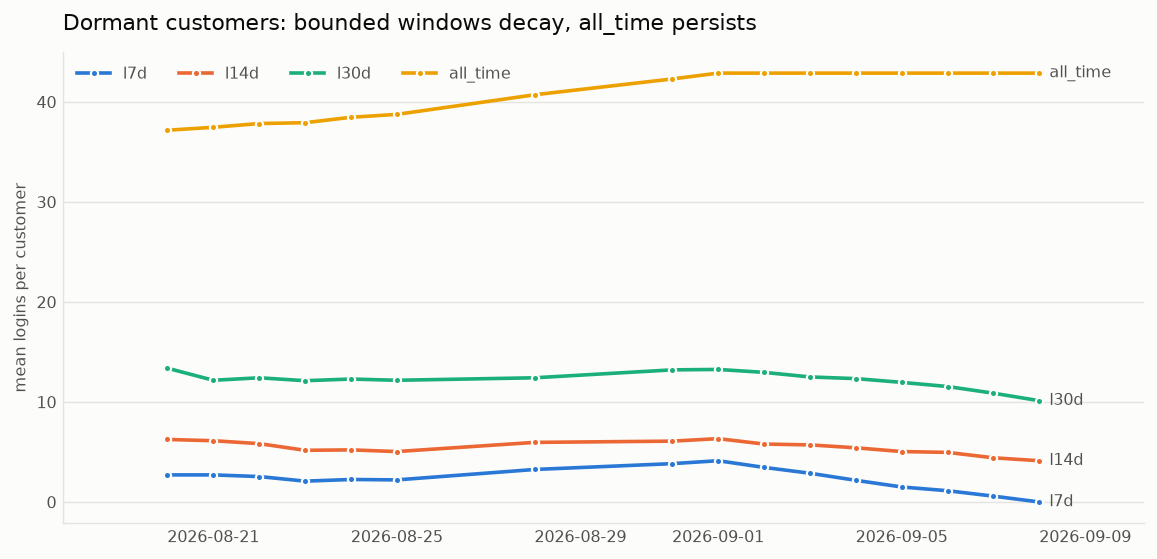

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Validated categorical slots 1-4 (blue, orange, aqua, yellow).
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
INK, INK_2, GRID = '#0b0b0b', '#52514e', '#e5e4e0'

def style(ax):
    ax.set_facecolor('#fcfcfb')
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.grid(axis='y', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK_2, labelsize=9, length=0)

cols = ['l7d', 'l14d', 'l30d', 'all_time']
x = pd.to_datetime(dormant.target_date)

fig, ax = plt.subplots(figsize=(9, 4.4), dpi=130)
fig.patch.set_facecolor('#fcfcfb')
for col, colour in zip(cols, SERIES):
    ax.plot(x, dormant[col], color=colour, linewidth=2, label=col,
            marker='o', markersize=4, markeredgecolor='#fcfcfb', markeredgewidth=1.2)
    # Direct labels are the relief the palette validator requires for the
    # low-contrast slots, and they remove the need to trace a legend.
    ax.annotate(f'  {col}', (x.iloc[-1], dormant[col].iloc[-1]),
                color=INK_2, fontsize=9, va='center')

ax.set_title('Dormant customers: bounded windows decay, all_time persists',
             color=INK, fontsize=12, loc='left', pad=12)
ax.set_ylabel('mean logins per customer', color=INK_2, fontsize=9)
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.legend(frameon=False, labelcolor=INK_2, fontsize=9, ncol=4, loc='upper left')
ax.margins(x=0.12)
style(ax)
plt.tight_layout(); plt.show()

## 4. Window monotonicity on real rows

A wider window is a superset of a narrower one, so counts can only grow with window
width. The same invariants run as dbt tests on every build; this is the visible
version of that check.

In [7]:
mono = con.execute('''
    select
      sum(case when count_event_id_l7d  > count_event_id_l14d     then 1 else 0 end) as l7_gt_l14,
      sum(case when count_event_id_l14d > count_event_id_l30d     then 1 else 0 end) as l14_gt_l30,
      sum(case when count_event_id_l30d > count_event_id_all_time then 1 else 0 end) as l30_gt_all,
      sum(case when min_event_timestamp_all_time > min_event_timestamp_l7d then 1 else 0 end) as min_ts_wrong,
      sum(case when max_event_timestamp_l7d > max_event_timestamp_all_time then 1 else 0 end) as max_ts_wrong,
      sum(case when min_days_since_login_l7d < min_days_since_login_all_time then 1 else 0 end) as days_since_wrong,
      count(*) as rows_checked
    from features
''').df().T.rename(columns={0: 'violations'})
mono

,violations
l7_gt_l14,0.0
l14_gt_l30,0.0
l30_gt_all,0.0
min_ts_wrong,0.0
max_ts_wrong,0.0
days_since_wrong,0.0
rows_checked,2755.0


In [8]:
# The days_since derivation, verified against its own definition rather than
# assumed: min(days since login) must equal the distance from the newest login.
derived = con.execute('''
    select count(*) as mismatches from features
    where max_event_timestamp_all_time is not null
      and min_days_since_login_all_time
          <> date_diff('day', cast(max_event_timestamp_all_time as date), target_date)
''').fetchone()[0]
print(f'days_since rows disagreeing with their source timestamp: {derived}')
assert derived == 0

days_since rows disagreeing with their source timestamp: 0


## 5. Exact vs approximate distinct

`device_id` keeps an exact key set - a customer owns a handful of devices. `event_id`
has one value per event, so its cardinality grows without bound and it uses a
fixed-size mergeable sketch instead. The trade is only acceptable if the error is
actually bounded, so here it is measured against exact ground truth.

In [9]:
DEV = 'fact_agg_features_login_device_v1'
con.execute(f"create or replace view device_features as select * from "
            f"read_parquet('s3://{BUCKET}/feature_store/{DEV}/*/*.parquet',"
            f" hive_partitioning=true)")

acc = con.execute('''
    select count_distinct_event_id_all_time as approx,
           count_event_id_all_time          as exact_upper_bound
    from device_features
    where target_date = (select max(target_date) from device_features)
''').df()

# event_id is unique per event, so the exact distinct count IS the row count.
acc['rel_error'] = (acc.approx - acc.exact_upper_bound).abs() / acc.exact_upper_bound
small = acc[acc.exact_upper_bound < 64]
large = acc[acc.exact_upper_bound >= 64]
print(f'below k=64 (sketch is complete, must be exact): {len(small)} entities, '
      f'max error {small.rel_error.max():.4%}')
print(f'at or above k=64 (estimated)                 : {len(large)} entities, '
      f'mean error {large.rel_error.mean():.2%}, p95 {large.rel_error.quantile(.95):.2%}')
assert small.rel_error.max() == 0, 'sketch under k must be exact'

below k=64 (sketch is complete, must be exact): 107 entities, max error 0.0000%
at or above k=64 (estimated)                 : 68 entities, mean error 6.00%, p95 18.05%


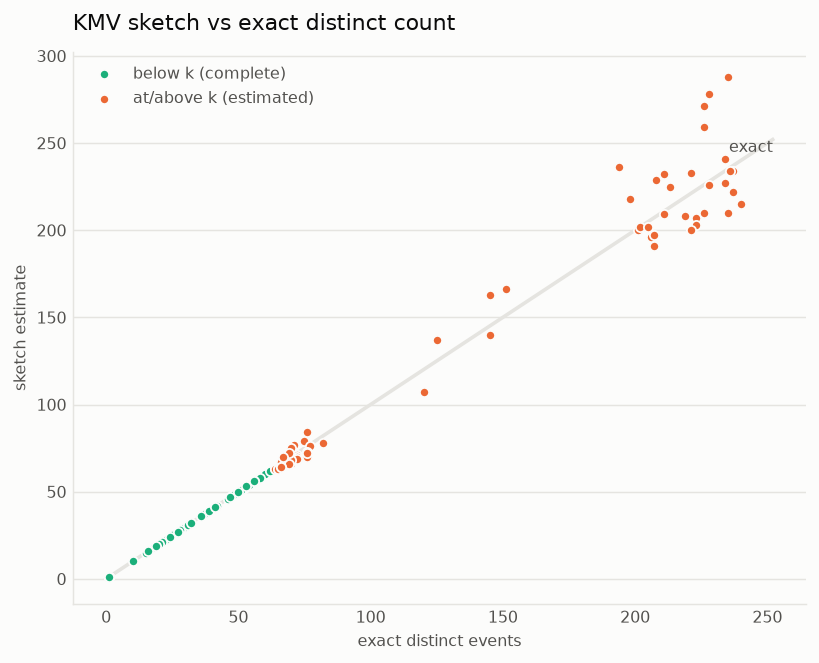

In [10]:
fig, ax = plt.subplots(figsize=(6.4, 5.2), dpi=130)
fig.patch.set_facecolor('#fcfcfb')
lim = acc.exact_upper_bound.max() * 1.05
ax.plot([0, lim], [0, lim], color=GRID, linewidth=2, zorder=1)
ax.annotate('  exact', (lim, lim), color=INK_2, fontsize=9, va='top', ha='right')
ax.scatter(small.exact_upper_bound, small.approx, s=26, color=SERIES[2],
           edgecolor='#fcfcfb', linewidth=1.0, zorder=3, label='below k (complete)')
ax.scatter(large.exact_upper_bound, large.approx, s=26, color=SERIES[1],
           edgecolor='#fcfcfb', linewidth=1.0, zorder=3, label='at/above k (estimated)')
ax.set_title('KMV sketch vs exact distinct count', color=INK, fontsize=12, loc='left', pad=12)
ax.set_xlabel('exact distinct events', color=INK_2, fontsize=9)
ax.set_ylabel('sketch estimate', color=INK_2, fontsize=9)
ax.legend(frameon=False, labelcolor=INK_2, fontsize=9, loc='upper left')
style(ax)
plt.tight_layout(); plt.show()

## 6. Assembling a training set

The workflow the whole system exists to serve.

Features are taken **as of** a cut-off date; the label is derived from what happened
**after** it. The two never overlap, so the split is leak-free by construction rather
than by careful SQL. `all_time` is what makes the label cheap: the difference between
two snapshots of a running total is exactly the activity between them.

Because the mart is one row per entity per as-of date, attaching features is an
equi-join on `(safe_id, target_date)`. Point-in-time correctness costs nothing at
query time - no range join, no window function, no chance of picking the wrong row.

In [11]:
bounds = con.execute('select min(target_date) as lo, max(target_date) as hi from features').df().iloc[0]
CUTOFF, OUTCOME = bounds.lo, bounds.hi
print(f'features as of {CUTOFF}   |   outcome observed through {OUTCOME}')

training = con.execute(f"""
    with at_cutoff as (
        select * from features where target_date = date '{CUTOFF}'
    ),
    at_outcome as (
        select safe_id, count_event_id_all_time as total_after
        from features where target_date = date '{OUTCOME}'
    )
    select
        c.safe_id,
        date '{CUTOFF}' as as_of,
        -- Strictly post-cut-off activity: the growth of a running total between
        -- two snapshots. Nothing at or before the cut-off can affect it.
        case when o.total_after > c.count_event_id_all_time then 0 else 1 end
            as churned_after_cutoff,
        c.count_event_id_l7d,
        c.count_event_id_l30d,
        c.count_event_id_all_time,
        c.count_distinct_device_id_all_time,
        c.min_days_since_login_all_time,
        c.count_event_id_is_login_failed_l30d,
        c.count_event_id_is_late_night_l30d
    from at_cutoff c
    join at_outcome o on o.safe_id = c.safe_id
""").df()

print(f'{len(training)} training rows, {training.shape[1] - 3} features')
print(f'churn rate: {training.churned_after_cutoff.mean():.1%}')
training.head()

features as of 2026-08-20 00:00:00   |   outcome observed through 2026-09-08 00:00:00
169 training rows, 7 features
churn rate: 20.1%


,safe_id,as_of,churned_after_cutoff,count_event_id_l7d,count_event_id_l30d,count_event_id_all_time,count_distinct_device_id_all_time,min_days_since_login_all_time,count_event_id_is_login_failed_l30d,count_event_id_is_late_night_l30d
0,cust_00110,2026-08-20,0,3.0,18.0,35.0,3,1,2.0,4.0
1,cust_00054,2026-08-20,0,23.0,108.0,173.0,1,0,16.0,23.0
2,cust_00081,2026-08-20,0,4.0,16.0,39.0,2,1,1.0,4.0
3,cust_00168,2026-08-20,0,11.0,27.0,46.0,1,0,4.0,6.0
4,cust_00082,2026-08-20,0,1.0,24.0,36.0,3,4,8.0,7.0


In [12]:
# The features should actually separate the label, or the pipeline is emitting
# columns that carry no signal.
sep = (training
       .groupby('churned_after_cutoff')[
           ['count_event_id_l7d', 'count_event_id_l30d',
            'count_event_id_all_time', 'min_days_since_login_all_time']]
       .mean().round(2))
sep.index = ['retained', 'churned']
sep

,count_event_id_l7d,count_event_id_l30d,count_event_id_all_time,min_days_since_login_all_time
retained,10.44,43.30,73.87,1.38
churned,0.09,1.15,17.12,26.26


In [13]:
# Feature-level sanity before any modelling: a column that is entirely null or
# entirely constant is either mis-specified or a wasted slot.
full = con.execute('select * from features where target_date = (select max(target_date) from features)').df()
feat_cols = [c for c in full.columns if not c.startswith('_')
             and c not in ('target_date', 'safe_id')]

prof = pd.DataFrame({
    'null_rate': full[feat_cols].isna().mean(),
    'distinct':  full[feat_cols].nunique(),
})
prof['constant'] = prof['distinct'] <= 1
print(f'{len(feat_cols)} feature columns')
print(f"  all-null    : {(prof.null_rate == 1).sum()}")
print(f"  constant    : {prof.constant.sum()}")
print(f"  informative : {(~prof.constant & (prof.null_rate < 1)).sum()}")
prof.sort_values('distinct', ascending=False).head(10)

480 feature columns
  all-null    : 0
  constant    : 0
  informative : 480


,null_rate,distinct,constant
max_event_timestamp_all_time,0.000000,175,False
min_event_timestamp_all_time,0.000000,174,False
min_event_timestamp_is_login_success_all_time,0.034286,169,False
max_event_timestamp_is_login_success_all_time,0.034286,169,False
min_event_timestamp_is_others_all_time,0.051429,166,False
max_event_timestamp_is_others_all_time,0.051429,166,False
min_event_timestamp_is_android_all_time,0.057143,165,False
min_event_timestamp_is_login_failed_all_time,0.057143,165,False
max_event_timestamp_is_login_failed_all_time,0.057143,165,False
max_event_timestamp_is_android_all_time,0.057143,165,False


---

Everything above ran against Parquet on object storage with no warehouse connection,
which is what makes the offline store usable by teams that will never have warehouse
credentials.